# Parameter space in Hough transform

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.size": 20,
})

In [2]:
def hough_figure(space, figsize=(8,3)):

    # Figure
    fig = plt.figure(figsize=figsize, facecolor="w")

    # Axe arrière, juste pour représenter la flèche
    ax0 = fig.add_axes([0, 0, 1, 1])
    ax0.set_axis_off()
    ax0.text(0.5, 0.5, "→", fontsize=26, ha='center', va='center')

    # Axes des deux graphes
    pos = [ (0, 0, .4, .95), (.6, 0, .4, .95) ]
    arrowprops = dict(arrowstyle="->", lw=1.2, mutation_scale=20)
    axs = []
    for i in range(2):
            
        # Axe
        ax = fig.add_axes(pos[i])    
        ax.set_axis_off()
        ax.set_xlim([-.1,1])
        ax.set_ylim([1,-.1])

        # Légende des axes
        if i == 0:
            x_label, y_label = "$x$", "$y$"
        if i == 1 and space=="ab":
            x_label, y_label = "$a$", "$b$"
        if i == 1 and space=="td":
            x_label, y_label = "$\\theta$", "$d$"

        # Abscisses
        ax.annotate("", xy=(1, 0), xytext=(-.1, 0), arrowprops=arrowprops)
        ax.text(1, -.05, x_label, ha='right', va='bottom')
        
        # # Ordonnées
        ax.annotate("", xy=(0, 1), xytext=(0, -.1), arrowprops=arrowprops)
        ax.text(-.05, 1, y_label, ha='right', va='bottom')
        
        axs.append(ax)
    
    return axs

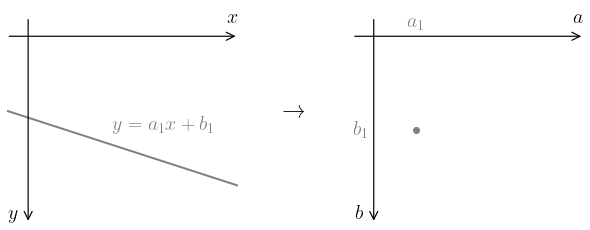

In [6]:
color = [.5, .5, .5]
ax1, ax2 = hough_figure(space="ab")

ax1.plot([-.1,1], [.4,.8], lw=2, color=color)
ax1.text(.4, .5, "$y=a_1x+b_1$", color=color)

ax2.plot(.2, .5, marker='o', color=color)
ax2.text(.2, -.05, "$a_1$", ha="center", color=color)
ax2.text(-.1, .5, "$b_1$", va="center", color=color)

plt.savefig("hough-ab-0.svg")
plt.show()

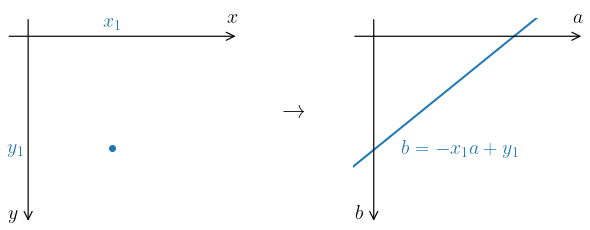

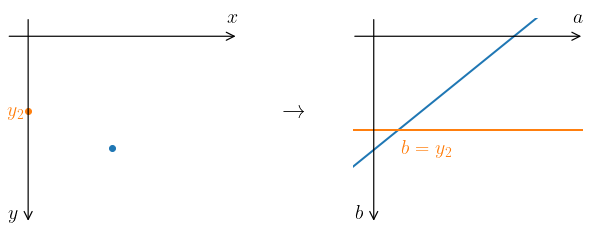

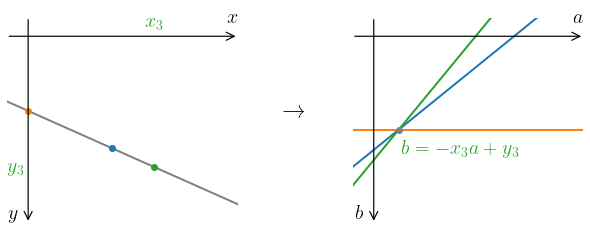

In [11]:
for n in range(1,4):
    
    ax1, ax2 = hough_figure(space="ab")
    
    # Premier point
    if n>=1:
        color = "C0"
        ax1.plot(.4, .6, marker='o', color=color)
        ax2.plot([-.1,1], [.7,-.3], lw=2, color=color)
    if n==1:
        ax1.text(.4, -.05, "$x_1$", ha="center", color=color)
        ax1.text(-.1, .6, "$y_1$", va="center", color=color)
        ax2.text(.13, .63, "$b=-x_1a+y_1$", color=color)
    
    # Deuxième point
    if n>=2:
        color = "C1"
        ax1.plot(.0, .4, marker='o', color=color)
        ax2.plot([-.1,1], [.5,.5], lw=2, color=color)
    if n==2:
        # ax1.text(.0, -.05, "$x_2$", ha="center", color=color)
        ax1.text(-.1, .4, "$y_2$", va="center", color=color)
        ax2.text(.13, .63, "$b=y_2$", color=color)
    
    # Troisième point
    if n>=3:
        color = "C2"
        ax1.plot(.6, .7, marker='o', color=color)
        ax1.text(.6, -.05, "$x_3$", ha="center", color=color)
        ax1.text(-.1, .7, "$y_3$", va="center", color=color)
        ax2.plot([-.1,1], [.8,-.7], lw=2, color=color)
        ax2.text(.13, .63, "$b=-x_3a+y_3$", color=color)
    
    # Ligne grise
    if n>=3:
        color = "gray"
        ax1.plot([-.1,1], [.35,.9], lw=2, color=color, zorder=1)
        ax2.plot(.12, .5, marker='o', color=color)
    
    plt.savefig(f"hough-ab-{n}.svg")
    plt.show()

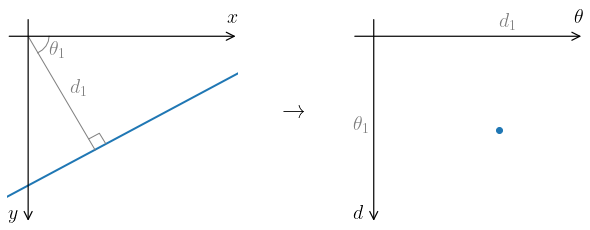

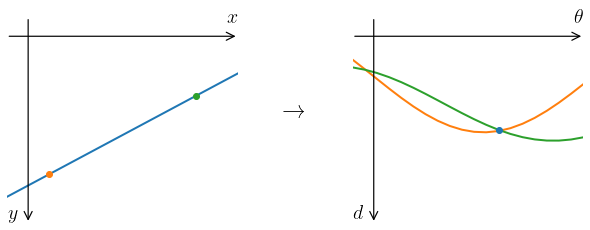

In [23]:
for n in range(1,3):
    
    ax1, ax2 = hough_figure(space="td")
    
    # Droite
    color = "C0"
    ax1.plot([-.1,1], [.86,.2], lw=2, color=color, zorder=1)
    ax2.plot(.6, .5, marker='o', color=color)
    
    # Perpendiculaire
    if n==1:
        color = "gray"
        ax1.plot([0,.32], [0,.61], lw=1, color=color)
        ax1.plot([.29,.34,.37], [.55,.52,.575], lw=1, color=color)
        tt = np.linspace(0,1.1,5)
        xx = .1*np.cos(tt)
        yy = .1*np.sin(tt)
        ax1.plot(xx, yy, lw=1, color=color)
        ax1.text(.2, .3, "$d_1$", color=color)
        ax1.text(.1, .1, "$\\theta_1$", color=color)
        ax2.text(.6, -.05, "$d_1$", color=color)
        ax2.text(-.1, .5, "$\\theta_1$", color=color)

    if n>=2:
        xx = np.linspace(-.1,1,20)
        
        # Sinusoïde 1
        color = "C1"
        ax1.plot(.1, .74, marker='o', color=color)
        ax2.plot(xx, .215 + .3 * np.sin(30*xx*.1), lw=2, color=color, zorder=1)
        
        # Sinusoïde 2
        color = "C2"
        ax1.plot(.8, .32, marker='o', color=color)
        ax2.plot(xx, .36 + .2 * np.sin(30*xx*.1-1), lw=2, color=color, zorder=1)
    
    plt.savefig(f"hough-td-{n}.svg")
    plt.show()